In [1]:
import pandas as pd
import numpy as np

In [2]:
workDir = "C:/Users/mjrubino/OneDrive - State of North Carolina/PAD-US/"
gitDir = workDir + "PAD-US-DMS-Scoresheet-Analysis/"
dfCatchSumm = pd.read_csv(gitDir+"catchment_summary.csv")
# Make sure rank and bin columns are integers
dfCatchSumm = dfCatchSumm.astype({'WQ_Rank': int, 'Hab_Rank': int, 'Hyd_Rank': int,
                                  'WQ_Bin': int, 'Hab_Bin': int, 'Hyd_Bin': int})
dfCatchSumm.head(5)

,COMID,WQ_uplift_,WQ_Cotype,WQ_DIS_ID,WQ_Rank,WQ_Bin,Hab_uplift,Hab_COtype,Hab_DIS_ID,Hab_Rank,...,Hab_TRA_V,Hyd_TRA_V,Service_Area_Name,River_Basin_Name,Shape_Length,Shape_Area,Catchment_Area,PAD_Area,PAD_Perc,PAD_Count
0,12034381,47.040001,NaN,NaN,952,7,83.440002,NaN,NaN,720,...,NO,NO,Broad,Broad,28561.683929,1.897749e+07,1.258561e+07,0.0,0.0,0
1,12034539,91.779999,HH,03050105_44,74,1,188.720001,HH,03050105_34,12,...,YES,YES,Broad,Broad,10456.713220,3.456620e+06,2.297701e+06,0.0,0.0,0
2,12034835,44.689999,NaN,NaN,1019,8,76.029999,NaN,NaN,858,...,NO,NO,Broad,Broad,3297.580686,4.416971e+05,2.944960e+05,0.0,0.0,0
3,12035521,48.439999,NaN,NaN,919,7,89.480003,NaN,03050105_37,638,...,YES,YES,Broad,Broad,3741.490617,2.311275e+05,1.539001e+05,0.0,0.0,0
4,12036671,34.830002,NaN,NaN,1230,9,73.730003,NaN,NaN,904,...,NO,NO,Broad,Broad,7448.280335,1.652284e+06,1.095300e+06,0.0,0.0,0


In [3]:
dfCatchSumm.shape

(68982, 30)

In [4]:
# Summary stats for the full dataset of catchments with or without PAD 1&2 polygons
dfCatchSumm[['PAD_Area', 'PAD_Perc']].describe().apply(lambda x: x.apply('{:.3f}'.format))

,PAD_Area,PAD_Perc
count,68982.000,68982.000
mean,113715.194,5.117
std,1135769.890,19.082
min,0.000,0.000
25%,0.000,0.000
50%,0.000,0.000
75%,0.000,0.000
max,118787847.579,100.000


In [5]:
# Get a subset of catchments that excludes those WITHOUT PAD polygons
dfPADonly = dfCatchSumm[dfCatchSumm['PAD_Perc']!=0]
dfPADonly.head(5)

,COMID,WQ_uplift_,WQ_Cotype,WQ_DIS_ID,WQ_Rank,WQ_Bin,Hab_uplift,Hab_COtype,Hab_DIS_ID,Hab_Rank,...,Hab_TRA_V,Hyd_TRA_V,Service_Area_Name,River_Basin_Name,Shape_Length,Shape_Area,Catchment_Area,PAD_Area,PAD_Perc,PAD_Count
25,12036765,56.070000,NaN,NaN,708,6,53.709999,NaN,NaN,1197,...,NO,NO,Broad,Broad,19217.748260,6.701283e+06,4.446002e+06,1.211542e+06,27.250000,2
31,12032721,72.919998,NaN,03050105_44,286,3,75.519997,NaN,NaN,867,...,NO,NO,Broad,Broad,16524.735361,8.438348e+06,5.574602e+06,1.178116e+06,21.129999,1
32,12034803,44.840000,NaN,NaN,1012,8,91.580002,NaN,NaN,609,...,NO,NO,Broad,Broad,15945.410960,6.243121e+06,4.161602e+06,1.971149e+05,4.740000,2
33,12032863,84.660004,HH,03050105_44,135,1,91.860001,NaN,NaN,601,...,NO,YES,Broad,Broad,16585.417492,7.848938e+06,5.188502e+06,2.905293e+05,5.600000,1
88,12034799,62.500000,NaN,NaN,533,4,68.900002,NaN,NaN,976,...,NO,NO,Broad,Broad,10653.190674,3.453766e+06,2.302201e+06,7.055899e+05,30.650000,2


In [6]:
dfPADonly.shape

(8952, 30)

In [7]:
for col in dfPADonly:
    print(col)

COMID
WQ_uplift_
WQ_Cotype
WQ_DIS_ID
WQ_Rank
WQ_Bin
Hab_uplift
Hab_COtype
Hab_DIS_ID
Hab_Rank
Hab_Bin
Hydro_upli
Hyd_Cotype
Hyd_DIS_ID
Hyd_Rank
Hyd_Bin
WQavgTRA
HABavgTRA
HYDavgTRA
WQ_TRA_V
Hab_TRA_V
Hyd_TRA_V
Service_Area_Name
River_Basin_Name
Shape_Length
Shape_Area
Catchment_Area
PAD_Area
PAD_Perc
PAD_Count


In [8]:
# Change cell CSS style to allow side-by-side dataframe display
from IPython.display import display, HTML

CSS = """
.output {
    flex-direction: row;
}
"""

HTML('<style>{}</style>'.format(CSS))

# Summary stats for only catchments with PAD 1&2 polygons
#   standard quartiles
x=dfPADonly[['PAD_Area', 'PAD_Perc']].describe().apply(lambda x: x.apply('{:.2f}'.format))
#   customized percentiles -> 10th, 25th, 50th, 75th, 90th
y=dfPADonly[['PAD_Area','PAD_Perc']].describe(percentiles=[0.1,0.25,0.5,0.75,0.9]).apply(lambda x: x.apply('{:.2f}'.format))
display(x)
display(y)


,PAD_Area,PAD_Perc
count,8952.00,8952.00
mean,876261.70,39.43
std,3045148.77,38.12
min,0.12,0.01
25%,30233.39,4.26
50%,179499.16,24.05
75%,760793.33,78.74
max,118787847.58,100.00


,PAD_Area,PAD_Perc
count,8952.00,8952.00
mean,876261.70,39.43
std,3045148.77,38.12
min,0.12,0.01
10%,4742.72,0.58
25%,30233.39,4.26
50%,179499.16,24.05
75%,760793.33,78.74
90%,2084106.92,100.00
max,118787847.58,100.00


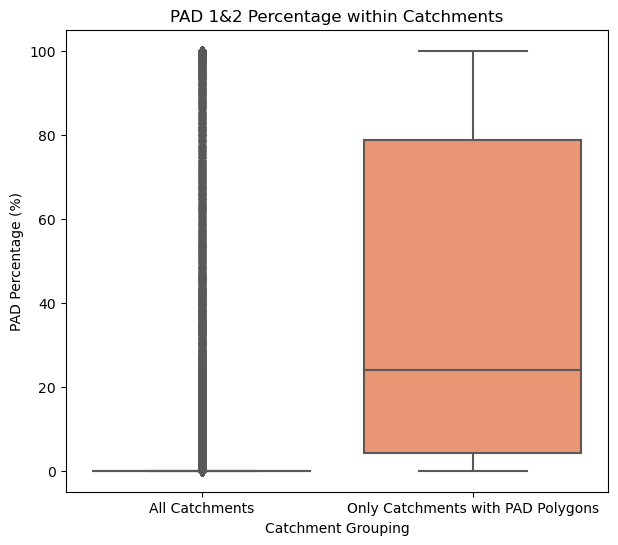

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a dataframe for all records
df_all = dfCatchSumm[['PAD_Perc']].copy()
df_all['Group'] = 'All Catchments'

# Create a dataframe for only non-zero records
df_non_zero = dfCatchSumm[dfCatchSumm['PAD_Perc'] != 0][['PAD_Perc']].copy()
df_non_zero['Group'] = 'Only Catchments with PAD Polygons'

# Concatenate the two dataframes
df_combined = pd.concat([df_all, df_non_zero])

# Create a single plot with both groups
plt.figure(figsize=(7, 6))
sns.boxplot(x='Group', y='PAD_Perc', data=df_combined, palette='Set2')

# Add labels and title
plt.title('PAD 1&2 Percentage within Catchments')
plt.ylabel('PAD Percentage (%)')
plt.xlabel('Catchment Grouping')

# Save the figure
plt.savefig('pad_perc_comparison.png')


<AxesSubplot: xlabel='Group', ylabel='PAD_Perc'>

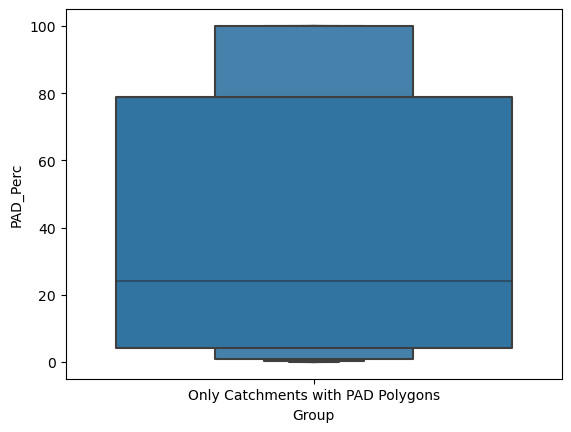

In [10]:
# This plot shows percentiles beyond the standard quartile range
# It is equivalent to the table illustrating customized percentile groups output above

sns.boxenplot(data=df_non_zero, x='Group', y='PAD_Perc')

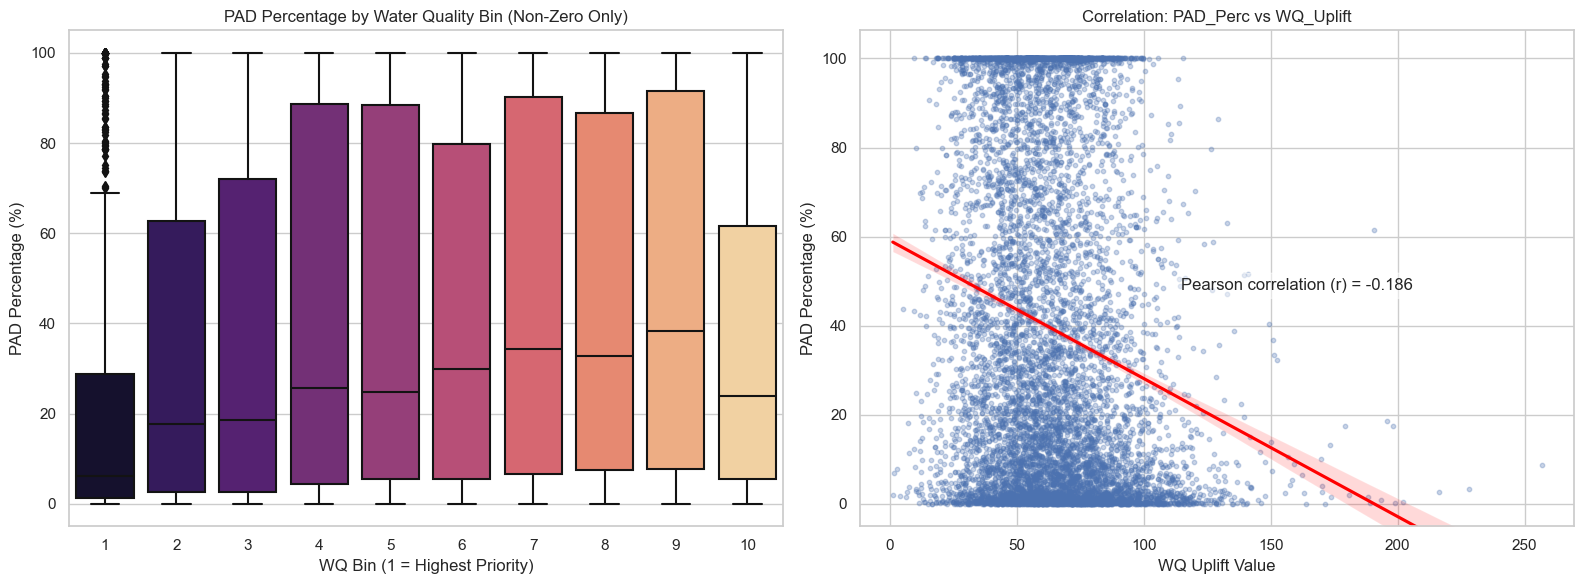

In [11]:
'''
    #### WATER QUALITY ####
'''

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
'''
# Load the dataset
df = pd.read_csv('catchment_summary.csv')

# Filter for records where PAD_Perc is not zero
df_filtered = df[df['PAD_Perc'] != 0].copy()

'''
df_filtered = dfPADonly

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PAD_Perc vs WQ_Bin (Categorized version of Rank/Uplift)
# This shows if higher priority bins have more/less protected land
sns.boxplot(x='WQ_Bin', y='PAD_Perc', data=df_filtered, ax=axes[0], palette='magma')
#axes[0].xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
axes[0].set_title('PAD Percentage by Water Quality Bin (Non-Zero Only)')
axes[0].set_xlabel('WQ Bin (1 = Highest Priority)')
axes[0].set_ylabel('PAD Percentage (%)')

# Plot 2: Relationship check using a Scatter with a regression line
# Since Uplift is continuous, a scatter plot is often more insightful than a boxplot
# Calculate the correlation coefficient
correlation = df_filtered['PAD_Perc'].corr(df_filtered['WQ_uplift_'])

sns.regplot(x='WQ_uplift_', y='PAD_Perc', data=df_filtered, ax=axes[1], 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})

plt.text(0.45, 0.5, f'Pearson correlation (r) = {correlation:.3f}', 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.ylim(bottom=-5)
axes[1].set_title('Correlation: PAD_Perc vs WQ_Uplift')
axes[1].set_xlabel('WQ Uplift Value')
axes[1].set_ylabel('PAD Percentage (%)')

plt.tight_layout()
plt.show()
del fig,axes,plt,correlation

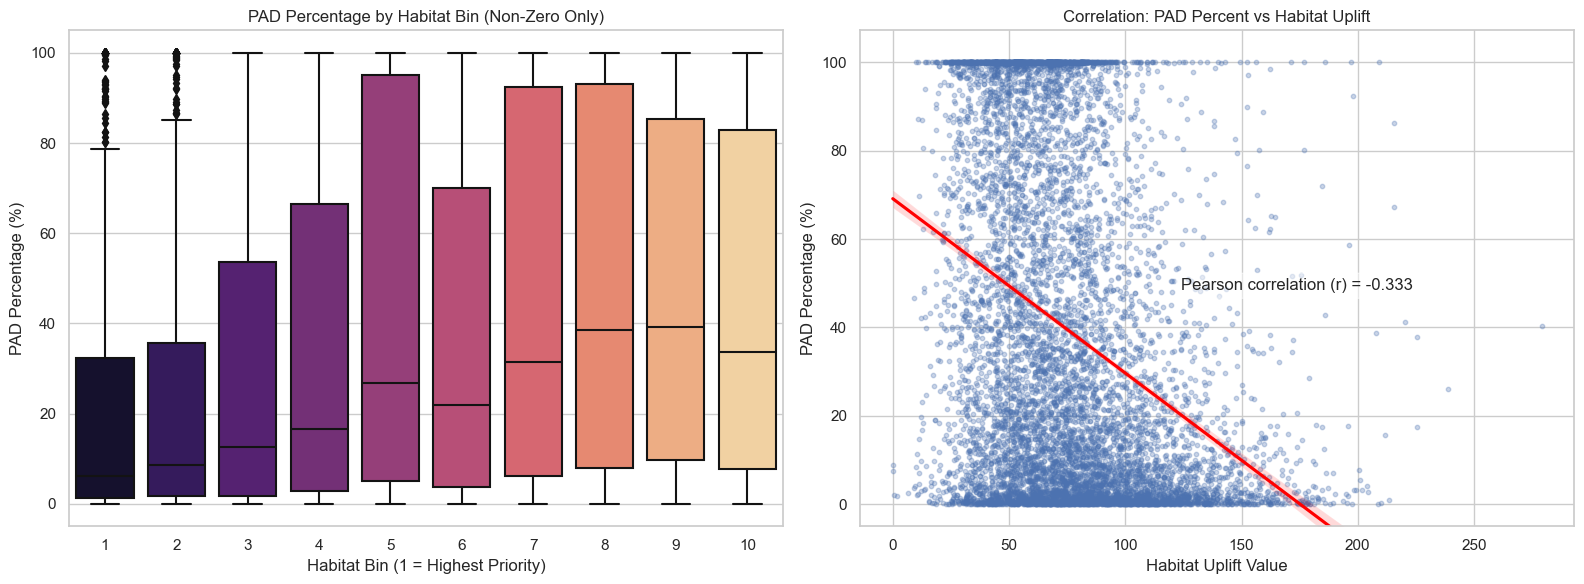

In [12]:
'''
    #### HABITAT ####
'''

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
'''
# Load the dataset
df = pd.read_csv('catchment_summary.csv')

# Filter for records where PAD_Perc is not zero
df_filtered = df[df['PAD_Perc'] != 0].copy()

'''
df_filtered = dfPADonly

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PAD_Perc vs Hab_Bin (Categorized version of Rank/Uplift)
# This shows if higher priority bins have more/less protected land
sns.boxplot(x='Hab_Bin', y='PAD_Perc', data=df_filtered, ax=axes[0], palette='magma')
#axes[0].xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
axes[0].set_title('PAD Percentage by Habitat Bin (Non-Zero Only)')
axes[0].set_xlabel('Habitat Bin (1 = Highest Priority)')
axes[0].set_ylabel('PAD Percentage (%)')

# Plot 2: Scatterplot of relationship between PAD % and Habitat Uplift
# Calculate the correlation coefficient for the title
correlation = df_filtered['PAD_Perc'].corr(df_filtered['Hab_uplift'])

sns.regplot(x='Hab_uplift', y='PAD_Perc', data=df_filtered, ax=axes[1], 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})

plt.text(0.45, 0.5, f'Pearson correlation (r) = {correlation:.3f}', 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.ylim(bottom=-5)
axes[1].set_title('Correlation: PAD Percent vs Habitat Uplift')
axes[1].set_xlabel('Habitat Uplift Value')
axes[1].set_ylabel('PAD Percentage (%)')

plt.tight_layout()
plt.show()
del fig,axes,plt,correlation

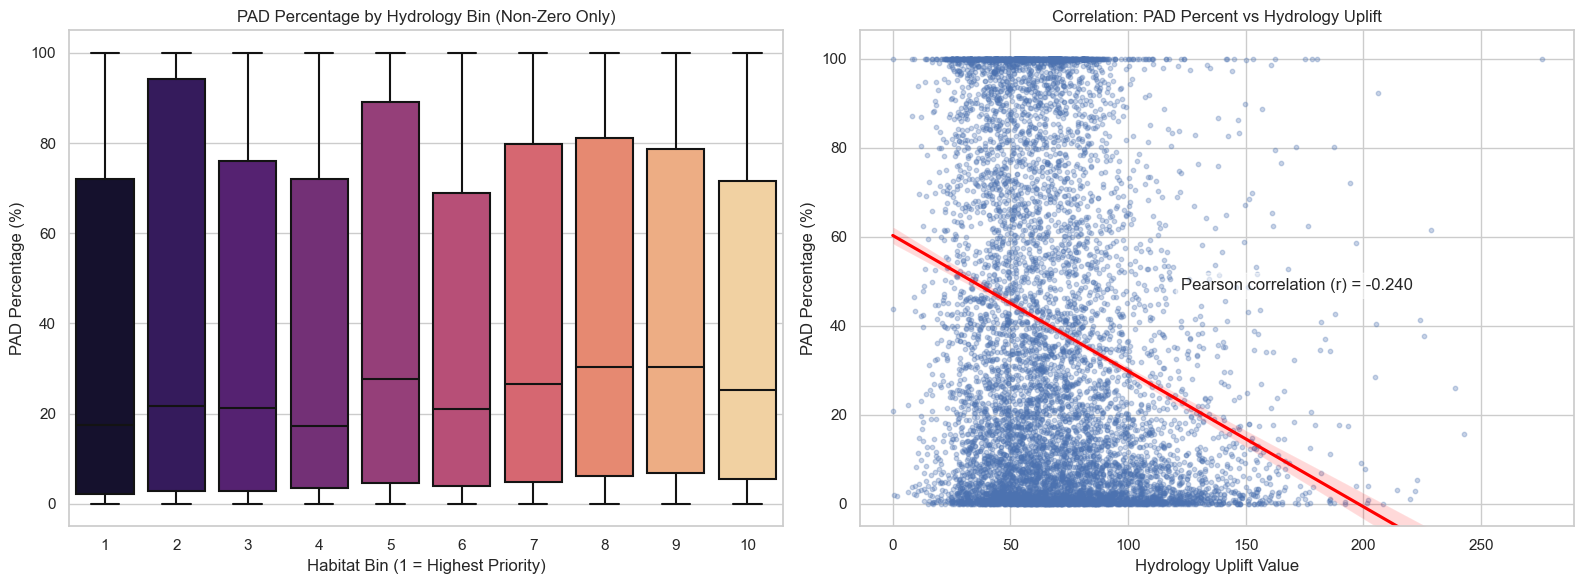

In [13]:
'''
    #### HYDROLOGY ####
'''
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
'''
# Load the dataset
df = pd.read_csv('catchment_summary.csv')

# Filter for records where PAD_Perc is not zero
df_filtered = df[df['PAD_Perc'] != 0].copy()

'''
df_filtered = dfPADonly

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: PAD_Perc vs Hyd_Bin (Categorized version of Rank/Uplift)
# This shows if higher priority bins have more/less protected land
sns.boxplot(x='Hyd_Bin', y='PAD_Perc', data=df_filtered, ax=axes[0], palette='magma')
#axes[0].xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))
axes[0].set_title('PAD Percentage by Hydrology Bin (Non-Zero Only)')
axes[0].set_xlabel('Habitat Bin (1 = Highest Priority)')
axes[0].set_ylabel('PAD Percentage (%)')

# Plot 2: Scatterplot of relationship between PAD % and Hydrology Uplift
# Calculate the correlation coefficient for the title
correlation = df_filtered['PAD_Perc'].corr(df_filtered['Hydro_upli'])

sns.regplot(x='Hydro_upli', y='PAD_Perc', data=df_filtered, ax=axes[1], 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})

plt.text(0.45, 0.5, f'Pearson correlation (r) = {correlation:.3f}', 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.ylim(bottom=-5)
axes[1].set_title('Correlation: PAD Percent vs Hydrology Uplift')
axes[1].set_xlabel('Hydrology Uplift Value')
axes[1].set_ylabel('PAD Percentage (%)')

plt.tight_layout()
plt.show()
del fig,axes,plt,correlation

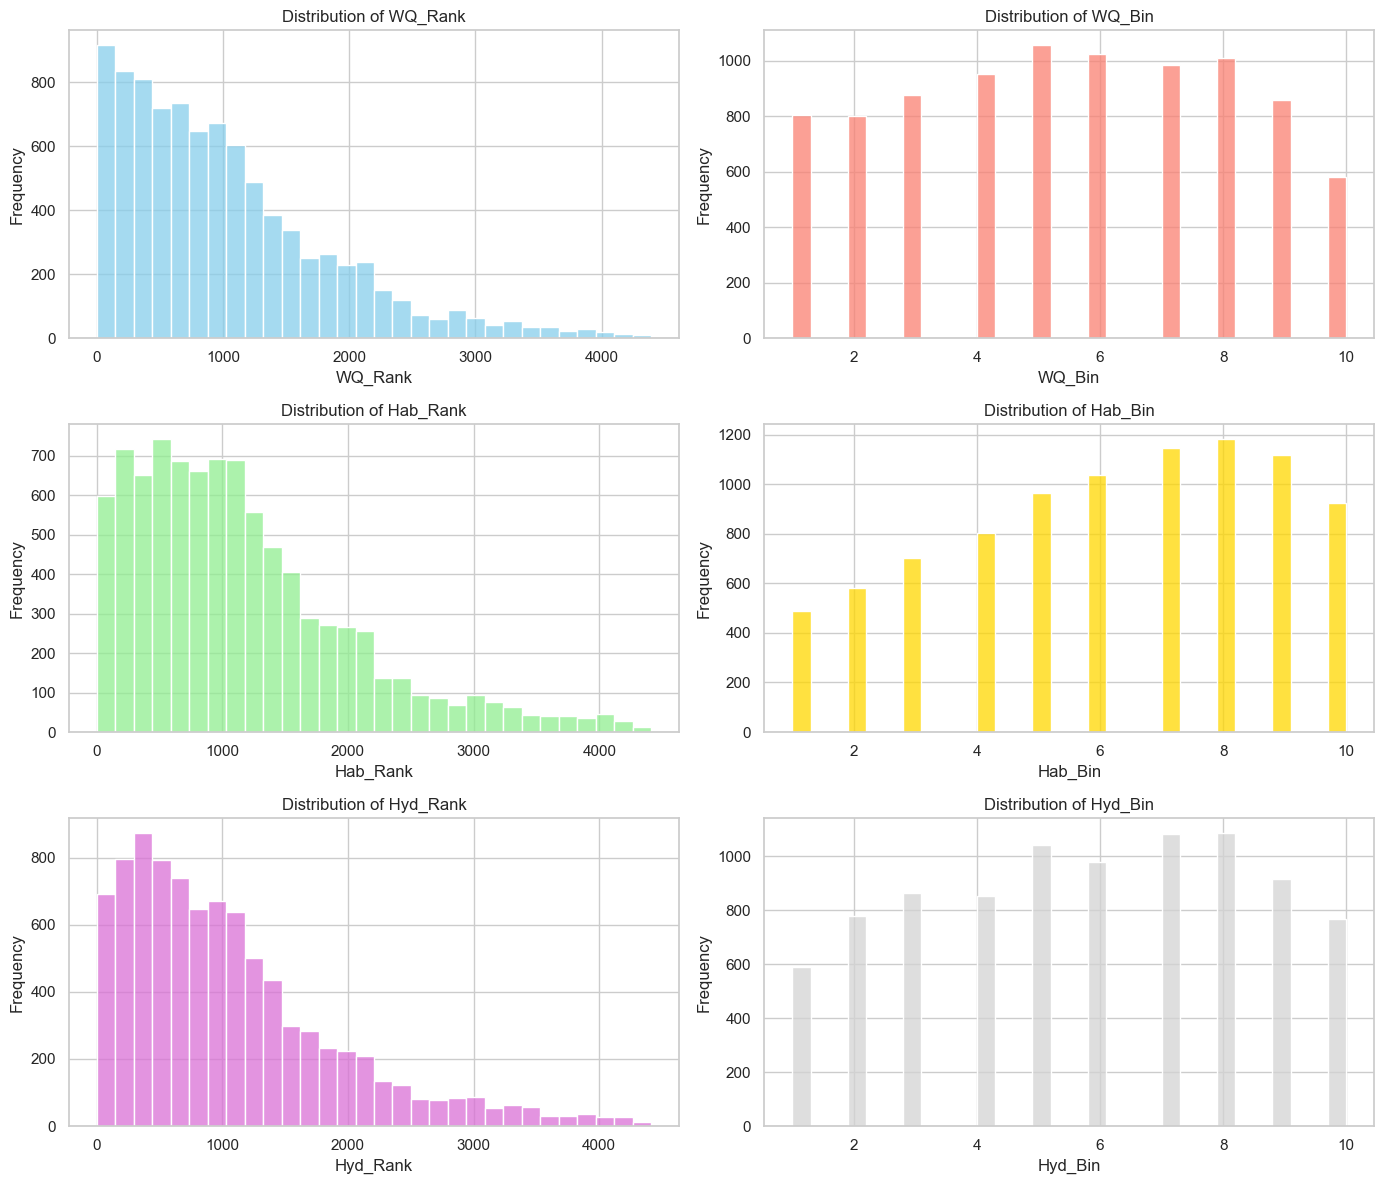

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# List of columns to plot in a grid
plot_cols = ['WQ_Rank', 'WQ_Bin', 'Hab_Rank', 'Hab_Bin', 'Hyd_Rank', 'Hyd_Bin']
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'orchid', 'lightgrey']

# Create a figure with a 3x2 grid of subplots
# This puts all variables on the "same plot" (one figure window)
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes_flat = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.histplot(dfPADonly[col], bins=30, kde=False, ax=axes_flat[i], color=colors[i])
    axes_flat[i].set_title(f'Distribution of {col}')
    axes_flat[i].set_xlabel(col)
    axes_flat[i].set_ylabel('Frequency')

# Adjust layout to prevent title overlapping
plt.tight_layout()
#plt.savefig('combined_histograms.png')
plt.show()